# Итоговое задание по дисциплине «Основы машинного обучения»

**Суть проекта** — построить модель классификации изображений, которая автоматически определяет класс объекта на картинке.

Сразу обозначим, что нейросети применять не придется — на этом наборе данных достаточно будет методов классического ML, а сам датасет уже подготовлен и содержит разделенные по столбцам пиксели. Зато можно задействовать все возможности ML: и обучение с учителем, и без учителя.

Постарайтесь оформить исследовательский ноутбук, провести эксперименты на разных этапах, найти наиболее подходящие алгоритмы, фиксируя промежуточные наблюдения в выводах. Чтобы обосновать выбор моделей и гиперпараметров, важно также провести разведывательный анализ данных и выполнить предварительную обработку данных.

Ниже найдете более подробную инструкцию по выполнению проекта.

**Критерии оценивания**

| Задание                                            | Балл      |
| -------------------------------------------------- | --------- |
| Задание 1        | 0.8 |
| Задание 2        | 0.8 |
| Задание 3        | 0.7 |
| Задание 4        | 1  |
| Задание 5        | 1.5  |
| Задание 6        | 2  |
| Задание 7        | 1.7 |
| Задание 8        | 1.5  |

## Описание данных

В работе используется известный набор данных **MNIST (Modified National Institute of Standards and Technology)** в его полной версии из `sklearn.datasets.fetch_openml`. Этот датасет предназначен для задачи классификации рукописных цифр и является одним из самых часто используемых бенчмарков в машинном обучении и компьютерном зрении.

Данные содержат набор изображений в градациях серого, каждое из них представлено в виде матрицы интенсивностей и соответствует одной из цифр.


In [1]:
pip install -q optuna


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ячейка с импортами — дополняйте по своему желанию
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math as m
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

## Задание 1. Знакомство с данными

Сначала познакомимся с датасетом:
1. Загрузите датасет с помощью [`sklearn.datasets.fetch_openml`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html).
2. Познакомьтесь с данными: проверьте наличие стандартных проблем по типу пропусков, дублей и ошибочных значений-выбросов. Что вообще можно считать выбросом в таком датасете?
3. Визуализируйте 5 случайных изображений, полезная функция для этого [`matplotlib.pyplot.imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html).
4. Сколько изображений в датасете и какого они размера? Достаточно ли этого для обучения ML-моделей?

Не забудьте зафиксировать все наблюдения в выводе.

In [3]:
# 1.1 - загрузка датасета
# mnist = fetch_openml("mnist_784", version=1, parser="auto")
# df = pd.concat([mnist["data"], mnist["target"]], axis=1)  # Собрал в единый df

df = pd.read_csv("./mnsit.csv").iloc[:, :]  # TODO удалить, и локальный файл тоже

df.sample()  # class == target

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
23920,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


Форма df:
         Строк:    70000
         Столбцов: 785

Тотальное количество пропусков: 0
Количество дублирующихся строк: 0

Диапазон значений признаков: 0 - 255
Диапазон значений таргета: 0 - 9


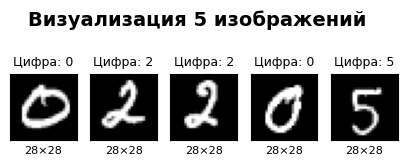

Полностью черные изображения отсутствуют: True
Полностью белые изображения отсутствуют:  True

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel1 to class
dtypes: int64(785)
memory usage: 419.2 MB


In [4]:
# 1.2 - Знакомлюсь с данными
print(f"Форма df:")
print(f"         Строк:{df.shape[0]:>9}")
print(f"         Столбцов:{df.shape[1]:>4}\n")
print(f"Тотальное количество пропусков: {
    df.loc[:, :].isna().sum().sum()
}")
print(f"Количество дублирующихся строк: {
    df.loc[:, :].duplicated().sum()
}\n")
print(f"Диапазон значений признаков: {df.min().min()} - {df.max().max()}")
print(f"Диапазон значений таргета: {df["class"].min()} - {df["class"].max()}")


# ============== Визуализирую 5 случайных изображений в сетке 2×3 ==============
square = lambda x: (m.sqrt(x) % 1 == 0, int(m.sqrt(x)))  # проверка на квадратность
fig, axes = plt.subplots(1, 5, figsize=(5, 5))
axes = axes.flatten()  # чтобы удобно перебирать по индексу
images = df.iloc[:, :-1].sample(5)
fig.suptitle(
    "Визуализация 5 изображений",
    fontsize=14,
    fontweight="bold",
    y=0.6,
)
for ax, image in enumerate(images.values):
    n_pixels = len(image)
    is_square, PIXEL = square(n_pixels)
    assert is_square, "Изображение не квадратное. Сворачиваемся..."
    axes[ax].imshow(image.reshape(PIXEL, PIXEL), cmap="gray")
    axes[ax].set_xticks([])
    axes[ax].set_yticks([])
    axes[ax].set_title(f"Цифра: {df.iloc[int(images.index[ax]), -1]}", size=9.)
    axes[ax].set_xlabel("%d×%d" % (PIXEL, PIXEL), fontsize=8)
plt.subplots_adjust(hspace=0.5, top=0.7)
plt.show()


# ======================== Полностью черные изображения ========================
p_max = int(df.max().max())  # максимальная интенсивность 
p_len = len(images.columns)  # количество пикселей
BLACK_P = df[df.iloc[:, :-1].sum(axis=1) == (p_max * p_len)]
print("Полностью черные изображения отсутствуют:", BLACK_P.empty)


# ======================== Полностью белые изображения =========================
white_p = df[df.iloc[:, :-1].sum(axis=1) == 0]
print(f"Полностью белые изображения отсутствуют:  {white_p.empty}\n", )


# ============================ Общая инфа о данных =============================
df.info()

df = df.astype(np.uint8)  # приведение типов с int64 -> int8

**<Вывод Задание 1>**  

Для выполнения задания я выгрузил данные в локальный файл `mnist.csv` чтобы его не загружать из интернета при каждом запуске. Позже я закомментировал код сохранения в локальный файл и его чтение.   
- Данные содержат 70 000 строк - наши изображения, 784 колонки - это яркость пикселя в градациях серого, а 785-я колонка-`class` - это наш таргет, т.е. реальная цифра, которая представлена на изображении. __Пропусков объектов и значений для них в данных нет__, __дубликатов также нет__. Общее количество изображений достаточное для выравнивания распределения целевых меток и обучения модели.  
- Стандартное RGB изображение допускает интенсивность цвета по трём каналам (от 0 до 255), __в нашем случае всего 1 канал__ - `gray` и он отражает интенсивность яркости пикселя в рамках тех-же значений(0-255). Итоговая проверка `диапазона значений одноканального изображения` показала, что __выбросы в интенсивности свечения пикселей отсутствуют (значений вне диапазона 0 - 255 нет)__.  
- `Проверка размерности` показала, что изображения имеют размер `28x28` ($\sqrt{784} = 28$) пикселей, в противном случае пришлось бы подбирать делитель и вычислять размер прямоугольного плоскогого изображения.  
- `Проверка визуализации` показала, что каждое из пяти случайных изображений соответствуют своей метке.  
- `Анализ df.info()` (сводной информации по данным) показал, что __данные имеют очень большой вес - 420MB__, это обусловлено тем, что на значения от 0 до 255 заданы типом данных int64, что вычислительно не рационально. Мы на каждый жалкий пиксель резервируем в оперативной памяти 64байта информации, а храним не больше 8 - это влияет на скорость обучения модели, поскольку получая числа из "железа" мы читаем весь участок в 64байта, а можем ограничиться 8-ю. __Последней строкой я выполнил приведение типов от int64 в uint8 (unsigned integeer 8байт сохраняет информацию в 256 чисел, т.е. от 0 до 255) - таким образом я снизил "вес" данных с 420MB до 50MB.__
- __Однотонных изображений в датасете нет.__

## Задание 2. Исследование данных

В CV особого классического EDA не провести, но базовые статистики и структуру данных все же можно проанализировать — особенно если перед нами задача классификации.

Проведите небольшой исследовательский анализ датасета, вот несколько пунктов для проверок (можете свободно дополнять их любыми своими идеями):

1. Проверьте распределение классов. Есть ли дисбаланс?
2. Посчитайте среднюю интенсивность пикселей по всему датасету и отдельно по каждому классу. Есть что-нибудь интересное?
3. Оцените долю полностью черных или почти пустых изображений (если такие есть).
4. Посчитайте и нарисуйте «среднее» изображение для каждого класса.

Не забудьте зафиксировать все наблюдения в выводе.

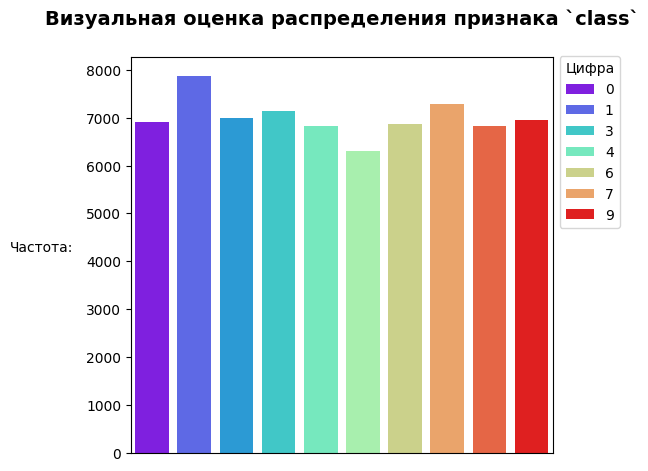

================Статистическая оценка распределения признака `class`================
Стандартное отклонение: 399.3158
Среднее значение количества классов: 7000
Коэффициент вариации (CV): 5.7045%
Данные сбалансированы: True


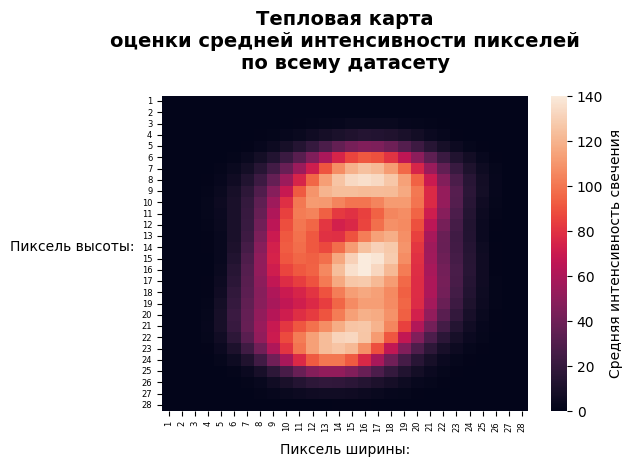

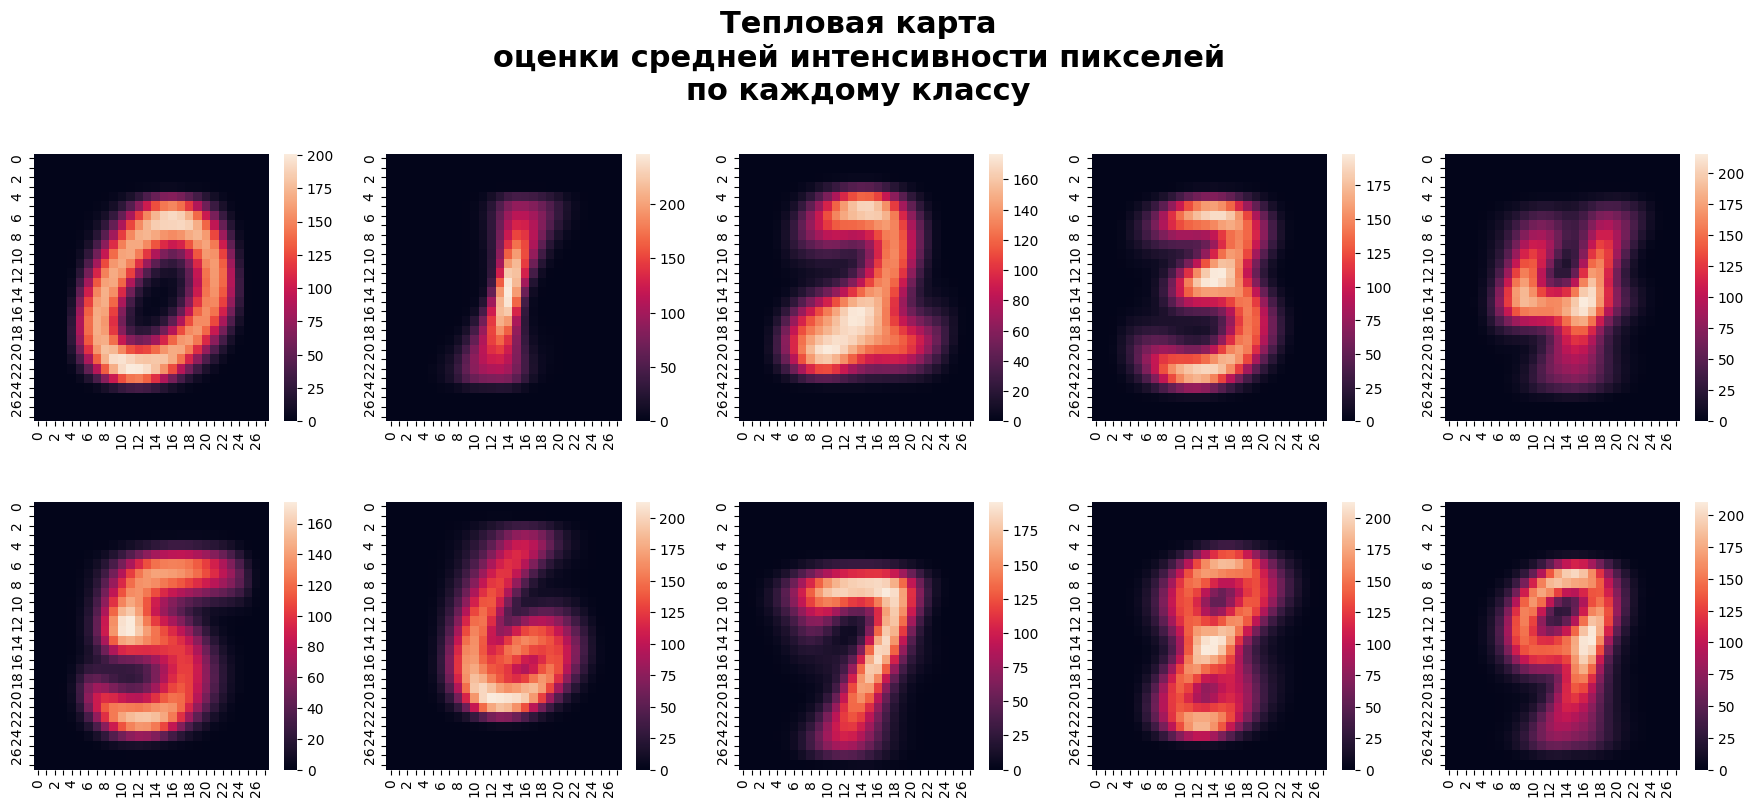

================Оценка доли полностью черных или почти пустых изображений================
Почти пустых изображений: 0 - 0.00%
Полностью чёрных: 0 - 0.00%


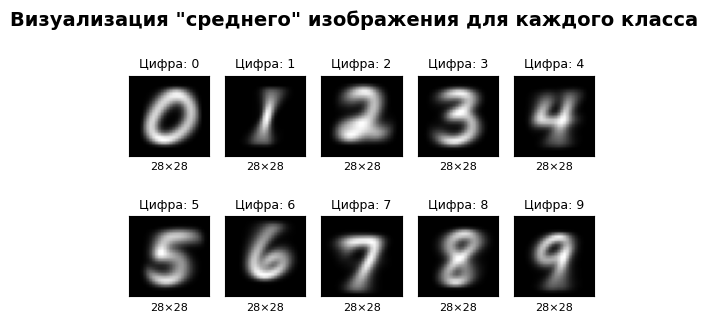

In [5]:
# Задание 2
# ============== Визуальная оценка распределения признака `class` ==============
df_value_counts = df["class"].value_counts()
plt.title("Визуальная оценка распределения признака `class`",
          fontsize=14,
          fontweight="bold",
          y=1.06)
sns.barplot(data=df_value_counts.reset_index(),
            x="class",
            y="count",
            palette="rainbow",
            hue="class")
plt.legend(bbox_to_anchor=(1.0, 1.02),
           title="Цифра")
plt.xlabel(""); plt.xticks([])
plt.ylabel("Частота:", rotation=0, labelpad=32)
plt.tight_layout()
plt.show()


# ============ Статистическая оценка распределения признака `class` ============
_ = "=" * 16
print(_ + "Статистическая оценка распределения признака `class`" + _)
df_std = df_value_counts.std()
df_mean = df_value_counts.mean()
sigma = df_std / df_mean * 100
print("Стандартное отклонение: %.4f" % df_std)
print("Среднее значение количества классов: %d" % df_mean)
print("Коэффициент вариации (CV): %.4f%%" % sigma)
print(f"Данные сбалансированы: {sigma < 10}")  # < 10% -True, иначе False


# ========== Оценка средней интенсивности пикселей по всему датасету ===========
def show_mean_pixel_intensity(ax, df: pd.DataFrame, mask: pd.Series=None):
    """ Вспомогательная Функция.
    Отображает оценку средней интенсивности пикселей
    """
    cbar_params = dict(cbar=True,
                       cbar_kws={"label": "Средняя интенсивность свечения"})
    if mask is not None:
        data = df[mask].iloc[:, :-1]
        cbar_params["cbar"] = True
        cbar_params["cbar_kws"] = {}
    else:
        data = df.iloc[:, :-1]
    mean_data = data.mean().values.reshape(PIXEL, PIXEL)
    sns.heatmap(mean_data, ax=ax, **cbar_params)
    ticks = np.arange(0.5, PIXEL, 1)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    if mask is None:
        ax.set_xlabel("Пиксель ширины:", labelpad=8, rotation=0)
        ax.set_ylabel("Пиксель высоты:", labelpad=50, rotation=0)
        tick_labels = range(1, PIXEL+1, 1)
        ax.set_xticklabels(tick_labels, rotation=90, size=6)
        ax.set_yticklabels(tick_labels, rotation=0,  size=6)


fig, ax = plt.subplots()
plt.title("Тепловая карта\nоценки средней интенсивности пикселей\n" +
          "по всему датасету",
          fontsize=14,
          fontweight="bold",
          y=1.06)
show_mean_pixel_intensity(ax, df)
plt.tight_layout()
plt.show()


# ========== Оценка средней интенсивности пикселей по каждому классу ===========
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
classes = sorted(df["class"].unique())
fig.suptitle("Тепловая карта\nоценки средней интенсивности пикселей\n" +
             "по каждому классу",
             fontsize=22,
             fontweight="bold",
             y=1.06)
for ax, df_class in enumerate(classes):
    show_mean_pixel_intensity(axes[ax], df, df["class"] == df_class)
plt.subplots_adjust(hspace=0.3)
plt.show()


# ========== Оценка доли полностью черных или почти пустых изображений =========
print(_ + "Оценка доли полностью черных или почти пустых изображений" + _)
# Проверяю почти пустые изображения
total = len(df)
gray_p = 128  # порог суммы пикселей: меньше 128 (серые)
almost_empty = df.iloc[:, :-1].sum(axis=1) < gray_p
almost_empty_cnt = almost_empty.sum()
print("Почти пустых изображений: " + 
     f"{almost_empty_cnt} - {almost_empty_cnt / total:.2%}")

# Проверяю полностью чёрные изображения
fully_black = len(BLACK_P)
print(f"Полностью чёрных: {fully_black} - {fully_black/total:.2%}")


# =========== Визуализирую "среднее" изображение для каждого класса ============
fig, axes = plt.subplots(2, 5, figsize=(6, 6))
axes = axes.flatten()
classes = sorted(df["class"].unique())
fig.suptitle(
    'Визуализация "среднего" изображения для каждого класса',
    fontsize=14,
    fontweight="bold",
    y=0.6,
)
for ax, df_class in enumerate(classes):
    class_img = df[df["class"] == df_class]
    mean_intensity = class_img.iloc[:, :-1].mean().values.reshape(PIXEL, PIXEL)
    axes[ax].imshow(mean_intensity, cmap="gray")
    axes[ax].set_xticks([])
    axes[ax].set_yticks([])
    axes[ax].set_title(f"Цифра: {df_class}", size=9)
    axes[ax].set_xlabel("%d×%d" % (PIXEL, PIXEL), fontsize=8)
plt.subplots_adjust(hspace=0.5, top=0.5)
plt.show()

**<Вывод Задание 2>**
- __Распределение классов:__ есть небольшое распределение таргета, однако, коэффициент вариации (5.7%) показал, что распределение близко к нормальному и данные более/менее однородны и имеют $\pm$ равномерное распределение при среднем значении количества классов в 7000. Это хорошоие новости. Не нужно будет искать что удалять для выравнивания.
- __Средняя интенсивность пикселей по всему датасету:__ по тепловой карте видно, что пиксели в целом располагаются в диапазоне __от 5 до 25го пикселя включительно по горизонтали__ и __от 4го до 26го пикселя включительно по вертикали__. Это говорит о том, что в среднем пиксели имеют некую концентрацию в середине изображения, которое, если его выделить, внутри будет содержать изображение числа. Такое изображение потенциально будет иметь разрешение примерно 23х23, т.е. у нас есть потенциал на уменьшение размерности. Также, стоит отметить, что ближе к центру изображения у нас имеются явно высокая концентрация пикселей.
- __Средняя интенсивность пикселей по каждому классу:__ в данном случае средняя интенсивность пикселей нам явно показывает, что, в среднем" изображения чисел явно различимы и их можно достаточно четко распознать. Каждая цифра меет свою максимальную интенсивность в строго определенных точках.
- __Анализ черных и пустых изображений:__ "черных" и "белых" квадратов 28х28 в датасете не выявлено, как и практически пустых.
- __Среднее изображение каждого класса__ просматривается достаточно чётко.

В общем: обучить модель паттернам представляется вполне возможным, поскольку каждое число в среднем имеет пиксели в строгих границах, которые практически не повторяются для соседних чисел. В таком случае мы решаем задачу не регрессии, а классификации и будем предсказывать вероятность отношения изображения к определенному классу. Вангую, что KNN может показать наилучшие результаты.

## Задание 3. Финальная подготовка

В данном случае предобработка изображений упрощена, поскольку данные уже представлены в виде таблицы пикселей. Однако для повышения качества будущих моделей можно применить кое-какие преобразования:

1. Если ранее обнаружились проблемы с данными, устраните их подходящим методом.  
2. Разделите датасет на обучающую, валидационную и тестовую выборки в соотношении 70/15/15 с фиксированным `random_state=42`. Не забудьте учесть дисбаланс классов при необходимости.
3. Масштабируйте изображения подходящим способом (методы sklearn использовать необязательно, можно вручную).

Обоснуйте выбор методов и проделанные шаги в кратком выводе.

In [6]:
# Задание 3

# ====================== Разделение на train, test и valid =====================
X = df.drop(columns=["class"])  #[:10000]
y = df["class"]  #[:10000]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=0.7, stratify=y, random_state=42
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
minmax_scaler = MinMaxScaler()
X_train_scaled = minmax_scaler.fit_transform(X_train)
X_test_scaled = minmax_scaler.transform(X_test)
X_valid_scaled = minmax_scaler.transform(X_valid)

# max = X.max().max()
# X_train_scaled = X_train / max
# X_test_scaled = X_test / max
# X_valid_scaled = X_valid / max

**<Вывод Задание 3>**

При разделении выборки на train test и valid следует учитывать, что данные для valid и test мы ерём по остаточному принципу после получения train. Далее необходимо разделить valid и test таким образом, чтобы сохранить их пропорции по отношению друг к другу и к train выборке. Для этого сперва получаем тренировочную и остаточную выборку temp, а затем делим temp на valid и test.  
Для данной задачи пиксели лучше мастабировать в диапазон значений [0, 1], поскольку это интуитивно понятно: чем выше значение, тем светлее пиксель.  
Также для данной задачи можно выполнить и ручное масштабирование путем деления всех значений выборок на 255(максимальное значение пикселя)

## Задание 4. Моделирование: baseline

В любых проектах сначала разрабатывают MVP (minimum viable product) — простейшее рабочее решение. В части ML-моделирования таковыми могут выступать baseline-алгоритмы — простейшие линейные модели. Поэтому с них и начнем:
1. Выберите наиболее подходящую метрику(метрики), на которую будете далее ориентироваться при сравнении моделей и для оценки качества в целом.
2. Попробуйте не менее двух линейных алгоритмов (гиперпараметры можно не подбирать).
3. Оцените качество по выбранной метрике и замерьте время обучения и инференса алгоритмов.
4. Являются ли данные линейно разделимыми? Наблюдается ли недообучение/переобучение (если есть переобучение, попробуйте его исправить методами регуляризации)? Что скажете про времязатратность процесса?

Обоснуйте все мысли в кратком выводе.

In [7]:
# Задание 4 - Обеспечающая часть
# ============================== Выбраные метрики ==============================
metrics = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted",
           "roc_auc_macro", "inference_time"]

# ========================== Выбраные Baseline модели ==========================
models = ["LogisticRegression", "SVC"]

# =========== Создание pd.DataFrame таблицы для сравнения результатов ==========
samples = ["train", "valid", "test"]
columns = pd.MultiIndex.from_product([models, samples])
METRICS = pd.DataFrame(index=metrics, columns=columns)

# ============== Вспомогательная функция внесения метрик в таблицу =============
def add_metrics_in_METRICS(model):
    """Вспомогательная функция добавления метрик в таблицу METRICS
    """
    model_name = model.__class__.__name__
    for sample, X_scaled, y_true in tuple(zip(samples,
                                            [X_train_scaled, X_valid_scaled,
                                            X_test_scaled],
                                            [y_train, y_valid, y_test])):
        i_start = time.perf_counter()
        y_pred = model.predict(X_scaled)
        y_proba = model.predict_proba(X_scaled)
        i_end = time.perf_counter()
        METRICS.loc["accuracy", (model_name, sample)] = accuracy_score(
            y_true, y_pred, 
        )
        METRICS.loc["precision_weighted", (model_name, sample)] = precision_score(
            y_true, y_pred, average="weighted"
        )
        METRICS.loc["recall_weighted", (model_name, sample)] = recall_score(
            y_true, y_pred, average="weighted"
        )
        METRICS.loc["f1_weighted", (model_name, sample)] = f1_score(
            y_true, y_pred, average="weighted"
        )
        METRICS.loc["roc_auc_macro", (model_name, sample)] = roc_auc_score(
            y_true, y_proba, multi_class='ovr', average='macro'
        )
        METRICS.loc["inference_time", (model_name, sample)] = i_end - i_start

METRICS

LogisticRegression              SVC           
                                train valid test train valid test
accuracy                          NaN   NaN  NaN   NaN   NaN  NaN
precision_weighted                NaN   NaN  NaN   NaN   NaN  NaN
recall_weighted                   NaN   NaN  NaN   NaN   NaN  NaN
f1_weighted                       NaN   NaN  NaN   NaN   NaN  NaN
roc_auc_macro                     NaN   NaN  NaN   NaN   NaN  NaN
inference_time                    NaN   NaN  NaN   NaN   NaN  NaN

In [8]:
# Задание 4 - Основная часть: Логистическая Регрессия

model = LogisticRegression()

# ================== Подгонка модели и замер времени обучения ==================
start = time.perf_counter()
model.fit(X_train_scaled, y_train)
end = time.perf_counter()
print("Время подгонки (с):", end - start)

# ============================== Добавление метрик =============================
add_metrics_in_METRICS(model)

# ================================ Оценка метрик ===============================
METRICS

/home/malkinte/.pyenv/versions/DL__MIPT/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Время подгонки (с): 14.588877228001365


LogisticRegression                       SVC           
                                train     valid      test train valid test
accuracy                     0.938571  0.920381  0.917524   NaN   NaN  NaN
precision_weighted           0.938469  0.920191  0.917171   NaN   NaN  NaN
recall_weighted              0.938571  0.920381  0.917524   NaN   NaN  NaN
f1_weighted                  0.938496  0.920205  0.917243   NaN   NaN  NaN
roc_auc_macro                0.995509  0.993816  0.992795   NaN   NaN  NaN
inference_time               0.203461  0.035792  0.047422   NaN   NaN  NaN

In [9]:
# Задание 4 - Основная часть: Метод опорных векторов

model = SVC(probability=True, kernel="linear")

# ================== Подгонка модели и замер времени обучения ==================
start = time.perf_counter()
model.fit(X_train_scaled, y_train)
end = time.perf_counter()
print("Время подгонки (с):", end - start)

# ============================== Добавление метрик =============================
add_metrics_in_METRICS(model)

# ================================ Оценка метрик ===============================
METRICS

Время подгонки (с): 610.0911887809998


LogisticRegression                             SVC  \
                                train     valid      test       train   
accuracy                     0.938571  0.920381  0.917524    0.974714   
precision_weighted           0.938469  0.920191  0.917171    0.974684   
recall_weighted              0.938571  0.920381  0.917524    0.974714   
f1_weighted                  0.938496  0.920205  0.917243    0.974678   
roc_auc_macro                0.995509  0.993816  0.992795    0.998992   
inference_time               0.203461  0.035792  0.047422  312.334985   

                                          
                        valid       test  
accuracy             0.936667   0.933429  
precision_weighted   0.936674   0.933434  
recall_weighted      0.936667   0.933429  
f1_weighted          0.936527   0.933272  
roc_auc_macro        0.996601   0.995863  
inference_time      65.453445  67.748105

**<Вывод Задание 4>**

Для решения данной задачи я создал единую мультииндексную таблицу pd.DataFrame для хранения сводной информации по метрикам. Также сделал вспомогательную функцию для добавления метрик обученных моделей в таблицу.  
**По метрикам:**
 - `Время подгонки (с)`: модель LogisticRegression обучилась достаточно быстро, однако это время обучения без подбора гиперпараметров, также "выпало" предупреждение о том, что градиент функции потерь модели не сошелся и стоит увеличить максимальное число итераций при подгонке модели. Линейный классификатор SVM осуществлял подгонку чуть больше 10 минут (что ооооочень долго). Для больших датасетов данная модель не подходит.
 - `accuracy` (доля правильных ответов): обе модели дают точность на тесте около 91-93%, что является достаточно хорошим результатом. Однако наблюдается небольшое переобучение: на тренировочной выборке accuracy каждой линейной модели выше чем на валидационной и тестовой. Данные не являются полностью линейно разделимыми, иначе точность была бы ближе к 100.  
 - `precision_weighted` (точность, взвешенная по поддержке классов): данная метрика подсказывает насколько модель редко ошибается, предсказывая положительный класс. Значения максимально близки к accuracy - это говорит о сбалансированной работе по всему таргету. Пропорциональное снижение на valid и test выборках подтверждает переобучение.  
 - `recall_weighted` (полнота, взвешенная по классам): на сколько точно модель находит все объекты целевого класса. Результат аналогичен метрике precision: пропорциональное снижение на valid и test выборках подтверждает переобучение.  
 - `f1_weighted` (гармоническое среднее precision и recall): несмотря на хороший баланс классов (аналитическая проверка сбалансированности классов, Задание 2) данная метрика подтверждает стабильность модели для всех классов: обладает предсказательной способностью на высоком уровне (достаточно хорошо разделяет классы).  
 - `roc_auc_macro` (площадь под ROC-кривой, усреднённая по классам (макро)): результат очень хороший - значения практически близки к 1.0, что говорит о высокой разделяющей способности моделей - они максимально точно различают цифры.
 - `inference_time` (время инференса(предсказания) на каждой выборке): LogisticRegression показала высокую скорость (менее 1 секунды на каждую выборку), в то время линейный классификатор SVM с параметром probability=True отработал очень медленно (что на этапе подгонки, что на этапе предсказаиня время заняло сотни и десятки секунд). Из чего я сделал вывод, что такое время выполнения недопустимо и данная модель для больших датасетов просто не подходит, хотя и имеет достаточно высокие метркии.

**Общие выводы по моделям:**
 - модель линейного классификатора SVM не используем - она не подходит ввиду большой выборки и долгой подгонки модели на этой выборке;  
 - для модели LogisticRegression для борьбы с переобучением можно попробовать усилить регуляризацию (уменьшить параметр C) и увеличить максимальное количество итераций для сходимости градиента функции потерь;  

>__Модель LogisticRegression показывает отличный баланс скорости и качества. Её можно взять за основу моего baseline.__

## Задание 5. Моделирование: деревянные алгоритмы

Теперь попробуем нелинейные алгоритмы:
1. Возьмите два «деревянных» алгоритма из sklearn — дерево решений и какой-нибудь ансамбль на его основе. Обучите для начала на базовых гиперпараметрах, аналогично замерьте время работы.
2. Посмотрите на качество по выбранной метрике на train/test. Если заметили переобучение/недообучение, попробуйте вручную подкрутить подходящие гиперпараметры, чтобы хоть как-то это исправить, и снова оцените по метрикам. В выводе обоснуйте, почему сделали тот или иной выбор.
3. Стало ли лучше по сравнению с baseline? Что скажете про времязатратность процесса — оправданно ли использование более сложных алгоритмов?

Обоснуйте все мысли в кратком выводе.

In [ ]:
"""
ВАШЕ РЕШЕНИЕ
"""

**<Вывод>**

## Задание 6. Моделирование: тяжелая артиллерия

Давайте обратимся к традиционно самым эффективным реализациям алгоритмов для табличных данных — продвинутым библиотекам CatBoost, XGBoost, LightGBM:

1. Выберите наиболее подходящий алгоритм и теоретически обоснуйте свой выбор /отличия от других невыбранных бустингов.
2. Обучите этот алгоритм, используя встроенные в библиотеку классы для датасетов (не возбраняется, если попробуете несколько алгоритмов, но достаточно будет и одного).
3. Подберите к нему гиперпараметры (не менее 5 шт.), используя специальные инструменты (не в цикле). Удалось ли улучшить качество? И что насчет временных затрат?

Обоснуйте все мысли в кратком выводе.

In [ ]:
"""
ВАШЕ РЕШЕНИЕ
"""

**<Вывод>**

## Задание 7. Оптимизация датасета

Помимо качества модели весьма важным критерием при выборе итогового решения является также ресурсоемкость и временные затраты — особенно для онлайн-решений, при больших датасетах или если нужно часто переобучать модель.

Как оптимизировать процесс? Когда терять качество модели не хочется, можно избавиться от лишних признаков. Особенно если их много, скорее всего, большая часть из них будет не слишком полезна.

В рамках этого задания попробуйте:
1. Применить PCA для понижения размерности, итоговое количество признаков подберите самостоятельно, опираясь на численные показатели (какие — обоснуйте в выводе).
2. Обучите на модифицированных данных наилучшую модель из предыдущих заданий (если ранее подбирали гиперпараметры, то можно повторно не делать).
3. Комплексно оцените качество и скорость работы модели. Насколько удалось ускорить решение и какой ценой? Какой вариант рекомендовали бы для финального production-решения?

Обоснуйте все мысли в кратком выводе.

In [ ]:
"""
ВАШЕ РЕШЕНИЕ
"""

**<Вывод>**

## Задание 8. Интерпретация результатов

Напоследок давайте сделаем еще несколько полезных визуализаций, которые будут интересны и нам для понимания данных и модели, и для презентаций заказчику:

1. Для финального выбранного решения постройте и визуализируйте матрицу ошибок на тестовом сете, чтобы наглядно проанализировать, какие классы путает модель. Зафиксируйте наблюдения в выводе.
2. Сделайте понижение размерности в 2D-пространство при помощи TSNE (гиперпараметры можете подобрать экспериментально) и визуализируйте полученную картину на scatterplot с раскраской по классам (таргетам). Хорошо ли данные разделяются в пространстве?

Не забудьте зафиксировать все наблюдения в выводе.

In [ ]:
"""
ВАШЕ РЕШЕНИЕ
"""

**<Вывод>**